In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import cv2
import matplotlib.pyplot as plt

# ✅ Correct base path (NO "- 2")
BASE_PATH = "/content/drive/MyDrive/PestNu Aphids - Whiteflies.v1i.yolov8"

TRAIN_IMG = os.path.join(BASE_PATH, "train/images")
TRAIN_LBL = os.path.join(BASE_PATH, "train/labels")

VAL_IMG = os.path.join(BASE_PATH, "valid/images")
VAL_LBL = os.path.join(BASE_PATH, "valid/labels")

TEST_IMG = os.path.join(BASE_PATH, "test/images")
TEST_LBL = os.path.join(BASE_PATH, "test/labels")

DATA_YAML = os.path.join(BASE_PATH, "data.yaml")


In [3]:
import cv2

def advanced_preprocess(image):
    # Edge-preserving noise removal
    bilateral = cv2.bilateralFilter(
        image,
        d=9,
        sigmaColor=75,
        sigmaSpace=75
    )

    # Contrast enhancement using CLAHE
    lab = cv2.cvtColor(bilateral, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)

    enhanced = cv2.merge((l, a, b))
    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2RGB)

    return enhanced


In [4]:
import matplotlib.pyplot as plt
import os

img_path = os.path.join(TRAIN_IMG, os.listdir(TRAIN_IMG)[0])
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


In [5]:
better_img = advanced_preprocess(image)


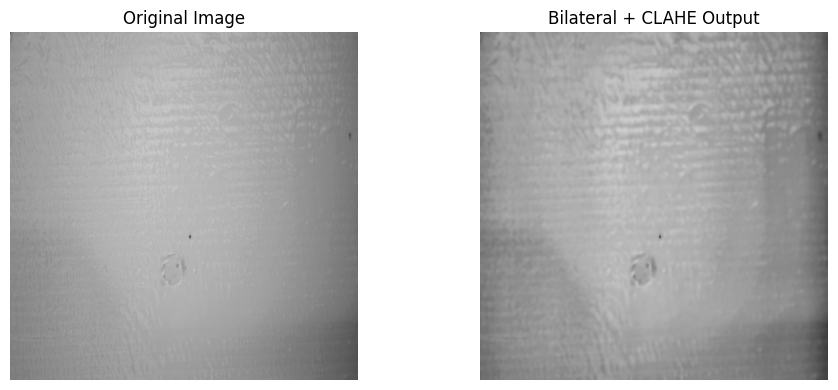

In [6]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(better_img)
plt.title("Bilateral + CLAHE Output")
plt.axis("off")
plt.tight_layout()
plt.show()


Image Processing

In [7]:
# Resize
prep_img = cv2.resize(better_img, (256, 256))


gray = cv2.cvtColor(prep_img, cv2.COLOR_RGB2GRAY)

# Normalize
norm_img = gray / 255.0

print(prep_img)
print(gray)
print(norm_img)


[[[ 95  95  95]
  [106 106 106]
  [112 113 112]
  ...
  [ 87  87  87]
  [ 87  87  87]
  [ 83  83  83]]

 [[107 107 107]
  [106 106 106]
  [114 113 113]
  ...
  [ 87  87  87]
  [ 84  84  84]
  [ 83  83  83]]

 [[113 113 113]
  [109 109 109]
  [115 115 115]
  ...
  [ 86  86  86]
  [ 82  82  82]
  [ 81  81  81]]

 ...

 [[107 107 107]
  [111 111 111]
  [113 114 113]
  ...
  [ 71  71  71]
  [ 68  68  68]
  [ 68  68  68]]

 [[108 108 108]
  [111 112 111]
  [113 114 113]
  ...
  [ 70  70  70]
  [ 68  68  68]
  [ 67  67  67]]

 [[108 108 108]
  [111 112 111]
  [113 114 113]
  ...
  [ 71  71  71]
  [ 68  68  68]
  [ 67  67  67]]]
[[ 95 106 113 ...  87  87  83]
 [107 106 113 ...  87  84  83]
 [113 109 115 ...  86  82  81]
 ...
 [107 111 114 ...  71  68  68]
 [108 112 114 ...  70  68  67]
 [108 112 114 ...  71  68  67]]
[[0.37254902 0.41568627 0.44313725 ... 0.34117647 0.34117647 0.3254902 ]
 [0.41960784 0.41568627 0.44313725 ... 0.34117647 0.32941176 0.3254902 ]
 [0.44313725 0.42745098 0.450980

Soble

In [8]:
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = cv2.magnitude(sobel_x, sobel_y)
print(sobel_x)
print(sobel_y)
print(sobel_mag)


[[  0.  48.  48. ... -18. -16.   0.]
 [  0.  32.  49. ... -23. -17.   0.]
 [  0.  14.  53. ... -32. -19.   0.]
 ...
 [  0.  26.   1. ... -17.  -9.   0.]
 [  0.  25.  -3. ... -14. -13.   0.]
 [  0.  24.  -4. ... -12. -14.   0.]]
[[  0.   0.   0. ...   0.   0.   0.]
 [ 42.  26.  11. ...  -7. -13. -14.]
 [ 26.  24.  25. ... -18. -23. -24.]
 ...
 [ 12.  12.   9. ...  -9. -11. -14.]
 [  4.   3.   1. ...  -2.  -1.  -2.]
 [  0.   0.   0. ...   0.   0.   0.]]
[[ 0.         48.         48.         ... 18.         16.
   0.        ]
 [42.         41.23105626 50.21951812 ... 24.04163056 21.40093456
  14.        ]
 [26.         27.78488798 58.6003413  ... 36.7151195  29.83286778
  24.        ]
 ...
 [12.         28.63564213  9.05538514 ... 19.23538406 14.2126704
  14.        ]
 [ 4.         25.17935662  3.16227766 ... 14.14213562 13.03840481
   2.        ]
 [ 0.         24.          4.         ... 12.         14.
   0.        ]]


Canny Edge Detector

In [9]:
edges = cv2.Canny(gray, threshold1=100, threshold2=200)
print(edges)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


HOG Texture + Shape

In [10]:
from skimage.feature import hog

hog_features, hog_image = hog(
    gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    visualize=True,
    block_norm='L2-Hys'
)
print(hog_features)
print(hog_image)


[0.26448222 0.23974545 0.16537786 ... 0.04463202 0.2536022  0.22561532]
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.51979017 0.         0.        ]
 [0.         0.         0.         ... 0.         0.55218208 0.        ]
 ...
 [0.         0.34600373 0.         ... 0.         0.25807024 0.        ]
 [0.         0.         0.49089602 ... 1.24297118 0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


In [11]:
from skimage.feature import local_binary_pattern

lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
print(lbp)

[[3. 3. 3. ... 9. 1. 3.]
 [2. 7. 5. ... 4. 4. 3.]
 [1. 6. 4. ... 4. 5. 3.]
 ...
 [4. 4. 1. ... 4. 7. 3.]
 [4. 4. 9. ... 5. 5. 5.]
 [3. 3. 1. ... 1. 3. 3.]]


Shape Feature Extraction

In [12]:
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

areas = [cv2.contourArea(cnt) for cnt in contours]
perimeters = [cv2.arcLength(cnt, True) for cnt in contours]
print(contours)
print(areas)
print(perimeters)

(array([[[124, 182]],

       [[121, 185]],

       [[120, 185]],

       [[119, 186]],

       [[118, 185]],

       [[117, 185]],

       [[116, 184]],

       [[116, 183]],

       [[114, 183]],

       [[114, 185]],

       [[113, 186]],

       [[114, 185]],

       [[114, 184]],

       [[115, 183]],

       [[116, 184]],

       [[116, 185]],

       [[117, 186]],

       [[118, 185]],

       [[119, 186]],

       [[120, 186]],

       [[121, 185]],

       [[122, 185]],

       [[124, 183]]], dtype=int32), array([[[113, 174]],

       [[111, 176]],

       [[112, 175]],

       [[113, 176]],

       [[113, 177]],

       [[112, 178]],

       [[112, 180]],

       [[113, 181]],

       [[112, 180]],

       [[112, 179]],

       [[113, 178]],

       [[114, 179]],

       [[113, 178]],

       [[113, 176]],

       [[112, 175]]], dtype=int32), array([[[125, 169]],

       [[125, 170]],

       [[124, 171]],

       [[123, 170]],

       [[122, 170]],

       [[123, 170]],

   

RGB Mean & Variance

In [13]:
mean_rgb = prep_img.mean(axis=(0,1))
std_rgb = prep_img.std(axis=(0,1))
print(mean_rgb)
print(std_rgb)

[156.03199768 156.05207825 155.99586487]
[22.08929421 22.10055355 22.1136659 ]


HSV Histogram

In [14]:
hsv = cv2.cvtColor(prep_img, cv2.COLOR_RGB2HSV)
hist_h = cv2.calcHist([hsv], [0], None, [180], [0,180])
print(hsv)
print(hist_h)

[[[  0   0  95]
  [  0   0 106]
  [ 60   2 113]
  ...
  [  0   0  87]
  [  0   0  87]
  [  0   0  83]]

 [[  0   0 107]
  [  0   0 106]
  [  0   2 114]
  ...
  [  0   0  87]
  [  0   0  84]
  [  0   0  83]]

 [[  0   0 113]
  [  0   0 109]
  [  0   0 115]
  ...
  [  0   0  86]
  [  0   0  82]
  [  0   0  81]]

 ...

 [[  0   0 107]
  [  0   0 111]
  [ 60   2 114]
  ...
  [  0   0  71]
  [  0   0  68]
  [  0   0  68]]

 [[  0   0 108]
  [ 60   2 112]
  [ 60   2 114]
  ...
  [  0   0  70]
  [  0   0  68]
  [  0   0  67]]

 [[  0   0 108]
  [ 60   2 112]
  [ 60   2 114]
  ...
  [  0   0  71]
  [  0   0  68]
  [  0   0  67]]]
[[6.1845e+04]
 [0.0000e+00]
 [0.0000e+00]
 [0.0000e+00]
 [0.0000e+00]
 [0.0000e+00]
 [0.0000e+00]
 [0.0000e+00]
 [0.0000e+00]
 [0.0000e+00]
 [0.0000e+00]
 [0.0000e+00]
 [0.0000e+00]
 [0.0000e+00]
 [0.0000e+00]
 [0.0000e+00]
 [0.0000e+00]
 [0.0000e+00]
 [0.0000e+00]
 [0.0000e+00]
 [0.0000e+00]
 [0.0000e+00]
 [0.0000e+00]
 [0.0000e+00]
 [0.0000e+00]
 [0.0000e+00]
 [0.00

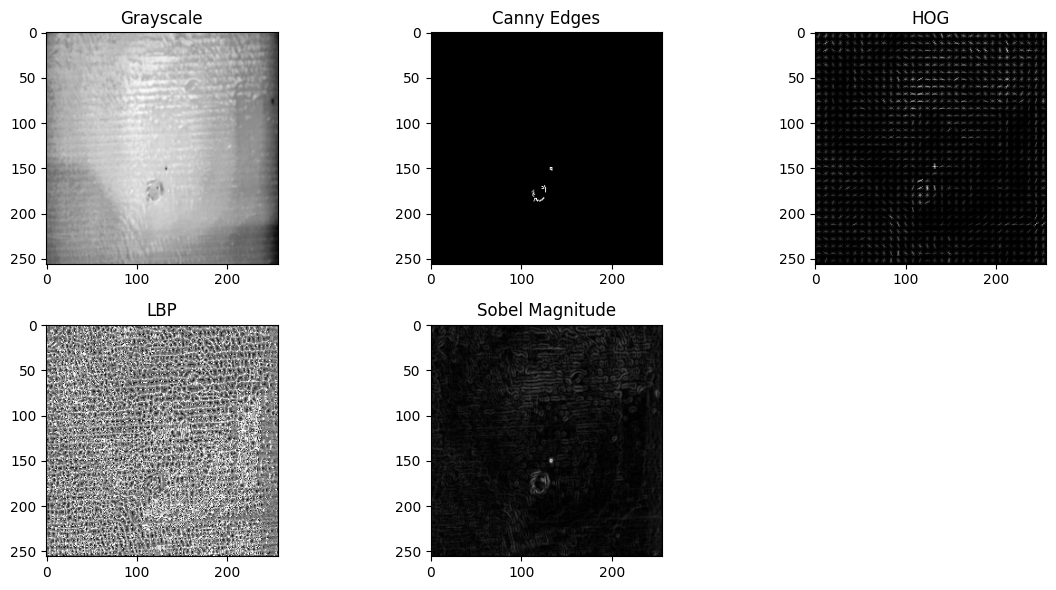

In [15]:
plt.figure(figsize=(12,6))

plt.subplot(2,3,1); plt.imshow(gray, cmap='gray'); plt.title("Grayscale")
plt.subplot(2,3,2); plt.imshow(edges, cmap='gray'); plt.title("Canny Edges")
plt.subplot(2,3,3); plt.imshow(hog_image, cmap='gray'); plt.title("HOG")
plt.subplot(2,3,4); plt.imshow(lbp, cmap='gray'); plt.title("LBP")
plt.subplot(2,3,5); plt.imshow(sobel_mag, cmap='gray'); plt.title("Sobel Magnitude")

plt.tight_layout()
plt.show()


CNN

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input, Dropout
import matplotlib.pyplot as plt
import numpy as np


In [17]:
img = cv2.resize(image, (224, 224))
img = img / 255.0
img = np.expand_dims(img, axis=0)


In [18]:
inputs = Input(shape=(224, 224, 3))

x = Conv2D(32, (3,3), activation='relu')(inputs)
x = MaxPooling2D(2,2)(x)

x = Conv2D(64, (3,3), activation='relu')(x)
x = MaxPooling2D(2,2)(x)

x = Conv2D(128, (3,3), activation='relu')(x)

# Feature extractor model
feature_model = Model(inputs, x)


In [19]:
feature_maps = feature_model.predict(img)
print(feature_maps)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
[[[[0.00000000e+00 2.39771120e-02 9.98940244e-02 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 2.36780569e-02 1.02334581e-01 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 2.33035255e-02 1.04485430e-01 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   ...
   [0.00000000e+00 1.83296762e-02 9.14469138e-02 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 1.77709535e-02 8.93002599e-02 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 1.75481942e-02 8.43908042e-02 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]]

  [[0.00000000e+00 2.47323327e-02 9.76447612e-02 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 2.43470669e-02 1.00393325e-01 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   [0.00000000e+00 2.63054259e-02 1.03600428e-01 ... 0.00000000e+00
    0.00000000e+00 0.00000000e+00]
   ...
   [0.00000000e+00 2.

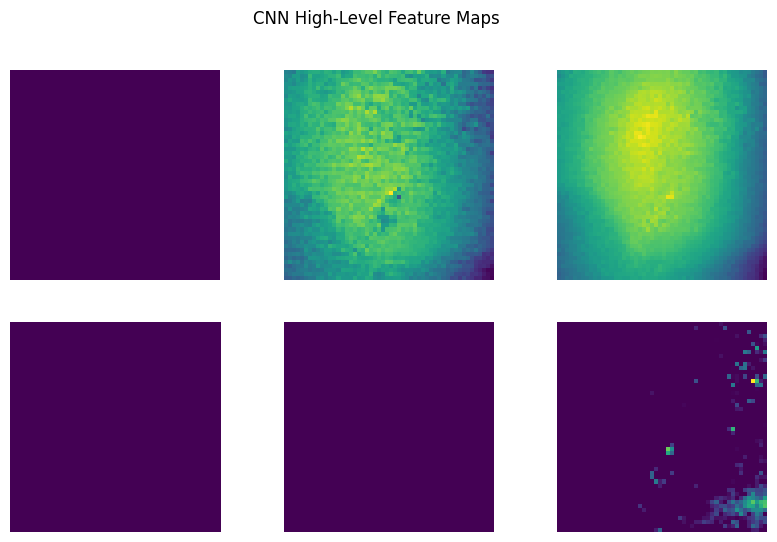

In [20]:
plt.figure(figsize=(10,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap='viridis')
    plt.axis('off')

plt.suptitle("CNN High-Level Feature Maps")
plt.show()


CNN Function With Own Activation Function

In [21]:
import tensorflow as tf

def my_custom_relu(x):
    """
    Custom activation:
    tanh(x) followed by ReLU
    """
    value_update = tf.math.tanh(x)
    return tf.maximum(0.0, value_update)


In [22]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input, BatchNormalization, Dropout

# 🔼 Increased input size
inputs = Input(shape=(256, 256, 3))

x = Conv2D(32, (3,3), padding='same', activation=my_custom_relu)(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D(2,2)(x)

x = Conv2D(64, (3,3), padding='same', activation=my_custom_relu)(x)
x = BatchNormalization()(x)
x = MaxPooling2D(2,2)(x)

x = Conv2D(128, (3,3), padding='same', activation=my_custom_relu)(x)
x = BatchNormalization()(x)
x = MaxPooling2D(2,2)(x)

# 🔼 Increased depth (extra layers)
x = Conv2D(256, (3,3), padding='same', activation=my_custom_relu)(x)
x = BatchNormalization()(x)

x = Conv2D(512, (3,3), padding='same', activation=my_custom_relu)(x)

# Feature extractor model
feature_model = Model(inputs, x)


In [23]:
feature_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 512)    │     1,180,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,570,496 (5.99 MB)

 Trainable params: 1,569,536 (5.99 MB)

 Non-trainable params: 960 (3.75 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


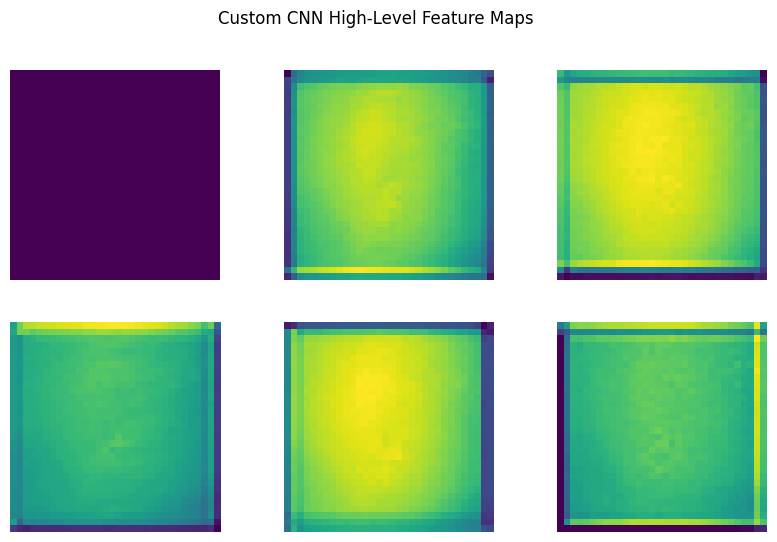

In [24]:
img = cv2.resize(image, (256, 256))
img = img / 255.0
img = np.expand_dims(img, axis=0)

feature_maps = feature_model.predict(img)

plt.figure(figsize=(10,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap='viridis')
    plt.axis('off')

plt.suptitle("Custom CNN High-Level Feature Maps")
plt.show()


YOLO

In [25]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 48.7 MB/s eta 0:00:00


In [26]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [27]:
yolo = YOLO("yolov8n.pt")
model = yolo.model
model.eval()


DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
    

In [28]:
img = cv2.resize(image, (640, 640))
img = img / 255.0
img = torch.tensor(img, dtype=torch.float32)
img = img.permute(2, 0, 1).unsqueeze(0)  # BCHW


In [29]:
feature_maps = []

def hook_fn(module, input, output):
    feature_maps.append(output)


hook = model.model[5].register_forward_hook(hook_fn)


In [30]:
with torch.no_grad():
    _ = model(img)
hook.remove()


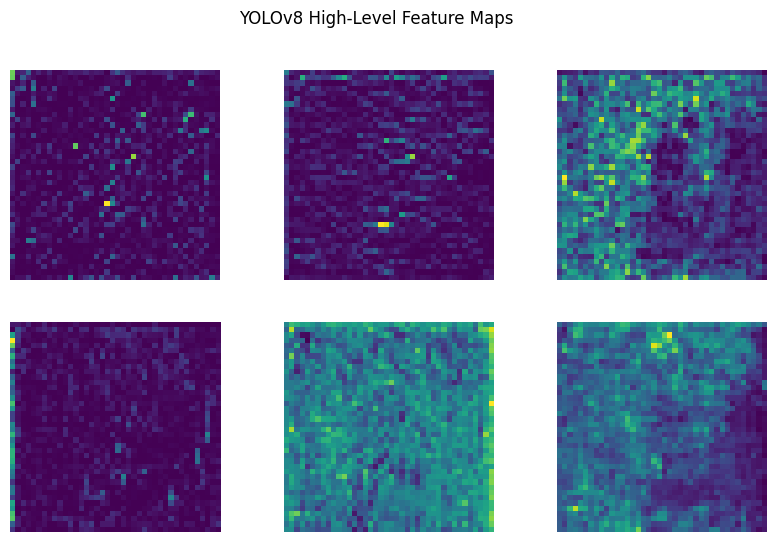

In [31]:
features = feature_maps[0].squeeze(0).cpu().numpy()

plt.figure(figsize=(10, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(features[i], cmap="viridis")
    plt.axis("off")

plt.suptitle("YOLOv8 High-Level Feature Maps")
plt.show()


YOLO With Own Activation Function

In [32]:
def my_custom_activation_yolo(x):
    """
    Custom activation:
    tanh followed by ReLU
    """
    x = np.tanh(x)
    return np.maximum(0, x)


In [33]:
# Apply custom activation to YOLO features
features_activated = my_custom_activation_yolo(features)


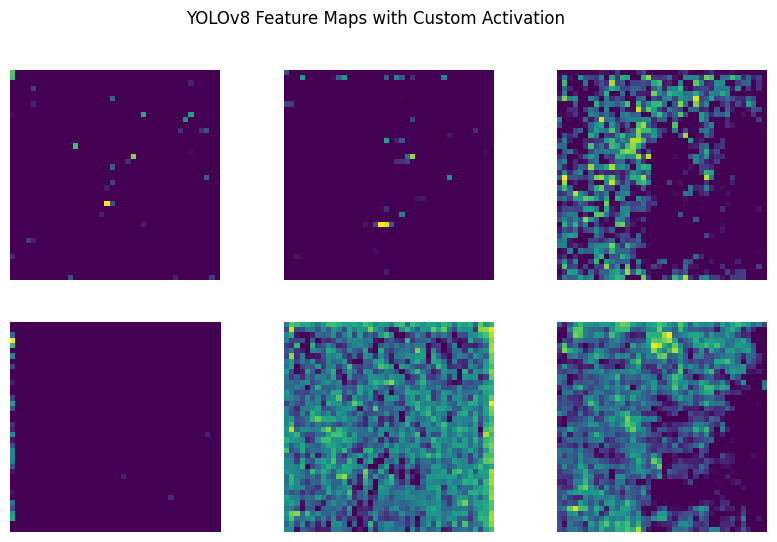

In [34]:
plt.figure(figsize=(10, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(features_activated[i], cmap="viridis")
    plt.axis("off")

plt.suptitle("YOLOv8 Feature Maps with Custom Activation")
plt.show()


Binary Prediction, Plottign, Accuray with CNN

In [35]:
import os
import cv2
import numpy as np

IMG_SIZE = 256

def load_cnn_data(img_dir, lbl_dir):
    X, y = [], []

    for img_name in os.listdir(img_dir):
        img_path = os.path.join(img_dir, img_name)
        lbl_path = os.path.join(lbl_dir, img_name.replace(".jpg", ".txt"))

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        # if any object exists → diseased (1)
        label = 1 if os.path.exists(lbl_path) and os.path.getsize(lbl_path) > 0 else 0

        X.append(img)
        y.append(label)

    return np.array(X), np.array(y)


In [36]:
X_train, y_train = load_cnn_data(TRAIN_IMG, TRAIN_LBL)
X_val, y_val = load_cnn_data(VAL_IMG, VAL_LBL)

print(X_train.shape, y_train.shape)


(158, 256, 256, 3) (158,)


In [37]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

def my_custom_relu(x):
    return tf.maximum(0.0, tf.math.tanh(x))

inputs = Input(shape=(256,256,3))

x = Conv2D(32, 3, padding='same', activation=my_custom_relu)(inputs)
x = MaxPooling2D()(x)

x = Conv2D(64, 3, padding='same', activation=my_custom_relu)(x)
x = MaxPooling2D()(x)

x = Conv2D(128, 3, padding='same', activation=my_custom_relu)(x)
x = MaxPooling2D()(x)

x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)

output = Dense(1, activation='sigmoid')(x)

cnn_model = Model(inputs, output)
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=16
)


Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9139 - loss: 0.4843 - val_accuracy: 1.0000 - val_loss: 0.0071
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 1.0000 - loss: 0.0046 - val_accuracy: 1.0000 - val_loss: 1.1682e-04
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 1.7420e-04 - val_accuracy: 1.0000 - val_loss: 3.0705e-05
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 8.5079e-05 - val_accuracy: 1.0000 - val_loss: 1.5244e-05
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 1.0000 - loss: 4.7352e-05 - val_accuracy: 1.0000 - val_loss: 9.9522e-06
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 2.3823e-05 - val_accuracy: 1.0000 - val_loss: 7.4619e-06
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 1.0000 - loss: 3.4100e-05 - val_accuracy: 1.0000 - val_loss: 5.8061e-06
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 1.000

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 409ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


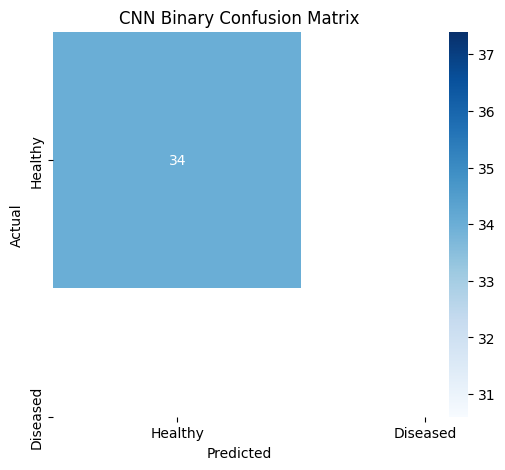

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        34

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [39]:
# ================= CONFUSION MATRIX (CNN BINARY) =================
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predict full validation set
y_pred_prob = cnn_model.predict(X_val)
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Healthy","Diseased"],
            yticklabels=["Healthy","Diseased"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Binary Confusion Matrix")
plt.show()

print(classification_report(y_val, y_pred))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
CNN Prediction Probability: 0.999997
CNN Class: DISEASED/PEST


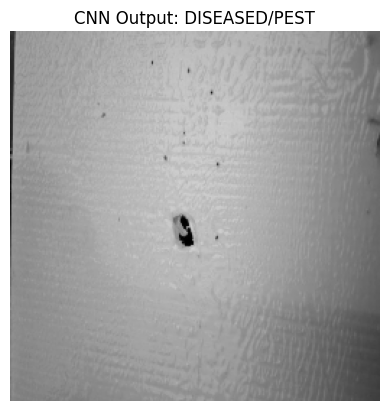

In [40]:
pred = cnn_model.predict(X_val[:1])[0][0]

print("CNN Prediction Probability:", pred)
print("CNN Class:", "DISEASED/PEST" if pred > 0.5 else "HEALTHY")

plt.imshow(X_val[0])
plt.title(f"CNN Output: {'DISEASED/PEST' if pred>0.5 else 'HEALTHY'}")
plt.axis("off")
plt.show()


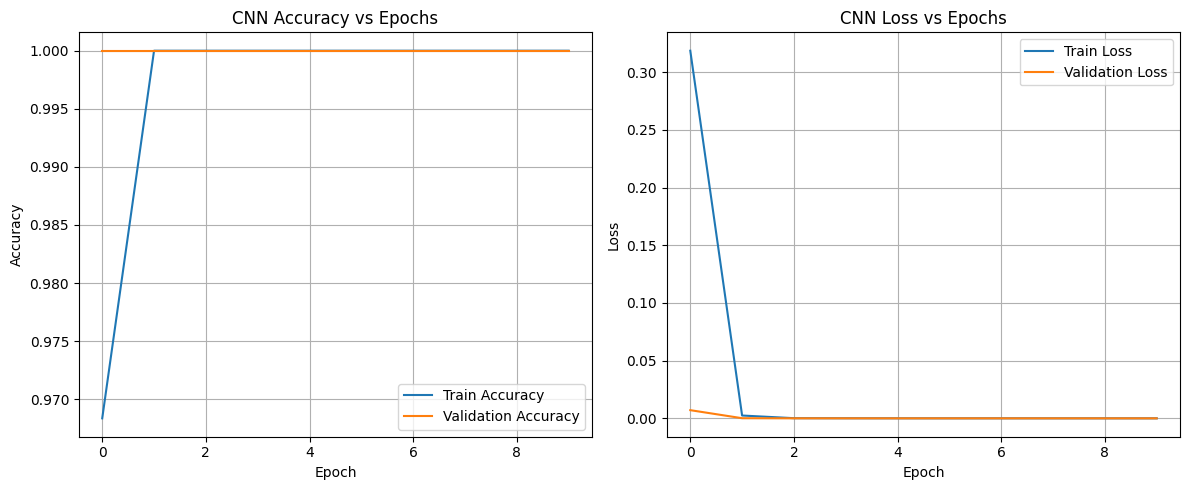

In [41]:
import matplotlib.pyplot as plt

# CNN Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy vs Epochs')
plt.legend()
plt.grid(True)

# CNN Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Loss vs Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [42]:
cnn_train_acc = history.history['accuracy'][-1]
cnn_val_acc = history.history['val_accuracy'][-1]

print(f"✅ Final CNN Training Accuracy: {cnn_train_acc*100:.2f}%")
print(f"✅ Final CNN Validation Accuracy: {cnn_val_acc*100:.2f}%")


✅ Final CNN Training Accuracy: 100.00%
✅ Final CNN Validation Accuracy: 100.00%


Binary Prediction, Plottign, Accuray with YOLO

In [43]:
import torch
from ultralytics import YOLO

yolo = YOLO("yolov8n.pt")
yolo_model = yolo.model
yolo_model.eval()

def extract_yolo_features(image):
    img = cv2.resize(image, (640,640))
    img = img / 255.0
    img = torch.tensor(img, dtype=torch.float32).permute(2,0,1).unsqueeze(0)

    feats = []
    def hook_fn(m, i, o): feats.append(o)

    hook = yolo_model.model[5].register_forward_hook(hook_fn)
    with torch.no_grad():
        _ = yolo_model(img)
    hook.remove()

    fmap = feats[0].squeeze(0)
    pooled = torch.mean(fmap, dim=(1,2))  # Global Avg Pool

    return pooled.cpu().numpy()


In [44]:
def load_yolo_cls_data(img_dir, lbl_dir):
    X, y = [], []

    for img_name in os.listdir(img_dir):
        img_path = os.path.join(img_dir, img_name)
        lbl_path = os.path.join(
            lbl_dir,
            img_name.rsplit(".", 1)[0] + ".txt"
        )

        # Load image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Extract YOLO features
        features = extract_yolo_features(img)

        # ✅ SAFE label logic
        if os.path.exists(lbl_path) and os.path.getsize(lbl_path) > 0:
            label = 1   # Diseased
        else:
            label = 0   # Healthy

        X.append(features)
        y.append(label)

    return np.array(X), np.array(y)


In [45]:
Xy_train, yy_train = load_yolo_cls_data(TRAIN_IMG, TRAIN_LBL)
Xy_val, yy_val = load_yolo_cls_data(VAL_IMG, VAL_LBL)

print(Xy_train.shape, yy_train.shape)
print(Xy_val.shape, yy_val.shape)


(158, 128) (158,)
(34, 128) (34,)


In [46]:
from tensorflow.keras.models import Sequential

yolo_cls = Sequential([
    Dense(256, activation='relu', input_shape=(Xy_train.shape[1],)),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

yolo_cls.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

yolo_cls.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,049 (258.00 KB)

 Trainable params: 66,049 (258.00 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:

yolo_history = yolo_cls.fit(
    Xy_train, yy_train,
    validation_data=(Xy_val, yy_val),
    epochs=10,
    batch_size=16
)



Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 274ms/step - accuracy: 0.9483 - loss: 0.3413 - val_accuracy: 1.0000 - val_loss: 0.0109
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 1.0000 - loss: 0.0059 - val_accuracy: 1.0000 - val_loss: 3.8171e-04
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 3.1230e-04 - val_accuracy: 1.0000 - val_loss: 6.8511e-05
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 6.6323e-05 - val_accuracy: 1.0000 - val_loss: 3.1875e-05
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 4.5093e-05 - val_accuracy: 1.0000 - val_loss: 2.2948e-05
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 3.0597e-05 - val_accuracy: 1.0000 - val_loss: 1.9865e-05
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 3.0484e-05 - val_accuracy: 1.0000 - val_loss: 1.8482e-05
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0

In [48]:
pred = yolo_cls.predict(Xy_val[:1])[0][0]

print("YOLO Prediction Probability:", pred)
print("YOLO Class:", "DISEASED/PEST" if pred > 0.5 else "HEALTHY")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
YOLO Prediction Probability: 0.9999845
YOLO Class: DISEASED/PEST


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
YOLO Prediction Probability: 0.9999845
YOLO Class: DISEASED/PEST


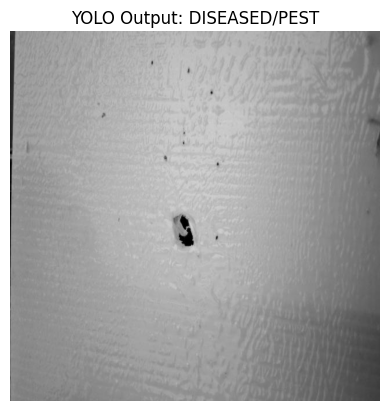

In [49]:
# Prediction
pred = yolo_cls.predict(Xy_val[:1])[0][0]

print("YOLO Prediction Probability:", pred)
print("YOLO Class:", "DISEASED/PEST" if pred > 0.5 else "HEALTHY")

# Load original image again for display
img_path = os.path.join(VAL_IMG, os.listdir(VAL_IMG)[0])

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(f"YOLO Output: {'DISEASED/PEST' if pred>0.5 else 'HEALTHY'}")
plt.axis("off")
plt.show()


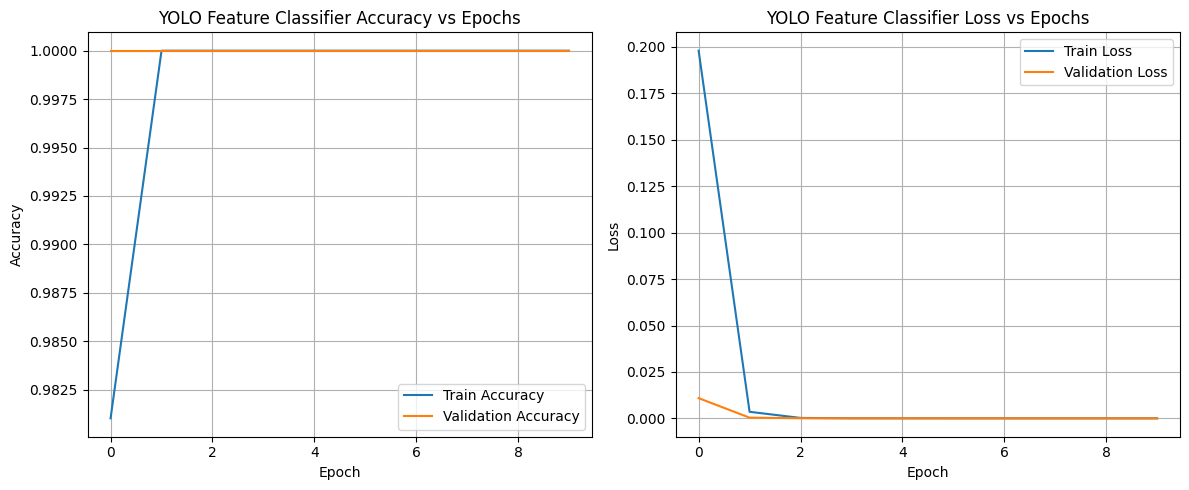

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(yolo_history.history['accuracy'], label='Train Accuracy')
plt.plot(yolo_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('YOLO Feature Classifier Accuracy vs Epochs')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(yolo_history.history['loss'], label='Train Loss')
plt.plot(yolo_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('YOLO Feature Classifier Loss vs Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [51]:
print(f"Final YOLO Training Accuracy: {yolo_history.history['accuracy'][-1]*100:.2f}%")
print(f"Final YOLO Validation Accuracy: {yolo_history.history['val_accuracy'][-1]*100:.2f}%")


Final YOLO Training Accuracy: 100.00%
Final YOLO Validation Accuracy: 100.00%


NasNet For Binary Classifiction Classification of Diseased/Pest (or) Healthy

In [52]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt


In [106]:
BASE = "/content/drive/MyDrive/PestNu Aphids - Whiteflies.v1i.yolov8"
IMG_DIR = BASE + "/train/images"
LBL_DIR = BASE + "/train/labels"

IMG_SIZE = 224


In [107]:
X = []
y = []

for img_name in os.listdir(IMG_DIR):

    img_path = os.path.join(IMG_DIR, img_name)
    lbl_path = os.path.join(LBL_DIR, img_name.replace(".jpg",".txt"))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE,IMG_SIZE))
    img = img/255.0

    # YOLO → Binary
    if os.path.exists(lbl_path) and os.path.getsize(lbl_path)>0:
        label = 1   # diseased
    else:
        label = 0   # healthy

    X.append(img)
    y.append(label)

X = np.array(X)
y = np.array(y)

print("Total images:",len(X))


Total images: 158


In [108]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [109]:
base = NASNetMobile(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base.trainable = False

feature_model = Model(
    base.input,
    tf.keras.layers.GlobalAveragePooling2D()(base.output)
)


In [57]:
X_train_feat = feature_model.predict(X_train, batch_size=8)
X_val_feat = feature_model.predict(X_val, batch_size=8)

print(X_train_feat.shape)


16/16 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
(126, 1056)


In [59]:
import numpy as np
print(np.unique(y_train))

[1]


In [ ]:
def predict_image(image_path):
    # Read image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_norm = img / 255.0

    # NASNet feature extraction
    feat = feature_model.predict(np.expand_dims(img_norm, 0))

    # SVM prediction
    p = svm.predict(feat)[0]
    prob = svm.predict_proba(feat)[0][1]

    # Show image
    plt.imshow(img_norm)
    plt.axis("off")


In [ ]:
show_random_predictions(15)


In [ ]:
print("Healthy:", np.sum(y==0))
print("Diseased:", np.sum(y==1))


*NasNet* For Binary Classifiction Classification of Diseased (or) Pest

In [113]:
import numpy as np
from collections import Counter

print("Unique labels:", np.unique(y_train))
print("Class distribution:", Counter(y_train))

Unique labels: [0]
Class distribution: Counter({np.int64(0): 118})


In [116]:
import os
import cv2
import numpy as np

X_features = []
y_labels = []

image_dir = "/content/drive/MyDrive/PestNu Aphids - Whiteflies.v1i.yolov8/train/images"
label_dir = "/content/drive/MyDrive/PestNu Aphids - Whiteflies.v1i.yolov8/train/labels"

for label_file in os.listdir(label_dir):

    label_path = os.path.join(label_dir, label_file)

    with open(label_path, "r") as f:
        line = f.readline().strip()
        class_id = int(line.split()[0])   # get class number

    image_name = label_file.replace(".txt", ".jpg")
    image_path = os.path.join(image_dir, image_name)

    img = cv2.imread(image_path)

    if img is None:
        continue

    img = cv2.resize(img,(64,64))
    feature = img.flatten()

    X_features.append(feature)
    y_labels.append(class_id)

print("Classes:", np.unique(y_labels))

Classes: [0 1]


In [118]:
from sklearn.model_selection import train_test_split

X_train_feat, X_test_feat, y_train, y_test = train_test_split(
    X_features,
    y_labels,
    test_size=0.2,
    stratify=y_labels,
    random_state=42
)

In [119]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train_feat, y_train)

print("SVM trained successfully")

SVM trained successfully


In [120]:
from sklearn.metrics import accuracy_score

y_pred = svm.predict(X_test_feat)

print("Accuracy:", accuracy_score(y_test, y_pred)*100)

Accuracy: 90.625


Total samples: 158
15/15 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Feature shape: (118, 1056)
CV Accuracy: 89.81884057971014
Train Accuracy: 96.61016949152543
Test Accuracy: 82.5
              precision    recall  f1-score   support

        PEST       0.94      0.86      0.90        37
     DISEASE       0.17      0.33      0.22         3

    accuracy                           0.82        40
   macro avg       0.55      0.60      0.56        40
weighted avg       0.88      0.82      0.85        40

1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


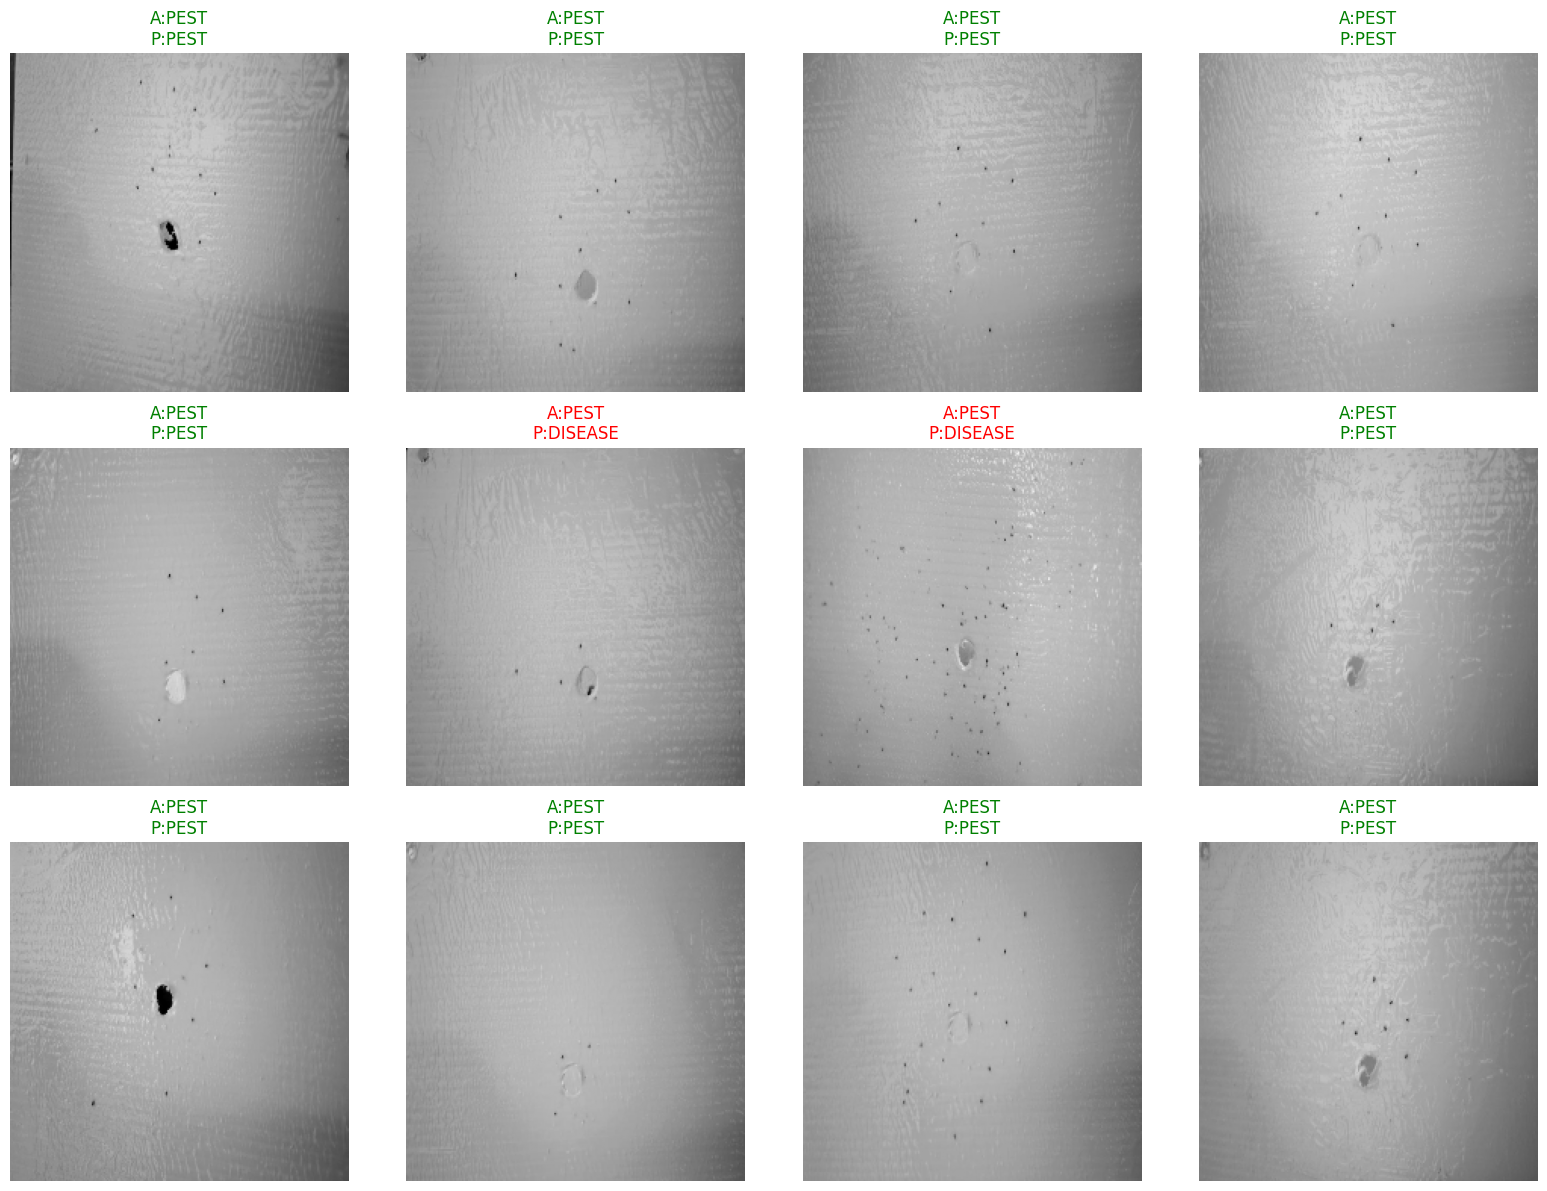

In [124]:
!pip install imbalanced-learn

import os, cv2, random, math
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.models import Model

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# ================= PATHS =================
BASE = "/content/drive/MyDrive/PestNu Aphids - Whiteflies.v1i.yolov8"
IMG_DIR = BASE + "/train/images"
LBL_DIR = BASE + "/train/labels"

IMG_SIZE = 224

PEST_CLASSES    = [0]
DISEASE_CLASSES = [1]

# ================= LOAD DATA =================
X, y = [], []

for img_name in os.listdir(IMG_DIR):

    img_path = os.path.join(IMG_DIR, img_name)
    lbl_path = os.path.join(LBL_DIR, img_name.replace(".jpg", ".txt"))

    if not os.path.exists(lbl_path):
        continue

    with open(lbl_path) as f:
        line = f.readline().strip()

    if line == "":
        continue

    cls = int(line.split()[0])
    if cls == 0:
      label = 0   # Aphids
    elif cls == 1:
      label = 1   # Whiteflies
    else:
      continue

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0

    X.append(img)
    y.append(label)

X = np.array(X)
y = np.array(y)

print("Total samples:", len(X))

# ================= SPLIT =================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# ================= NASNET FEATURE EXTRACTOR =================
base = NASNetMobile(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
base.trainable = False

feature_model = Model(
    base.input,
    tf.keras.layers.GlobalAveragePooling2D()(base.output)
)

X_train_feat = feature_model.predict(X_train, batch_size=8)
X_test_feat  = feature_model.predict(X_test, batch_size=8)

print("Feature shape:", X_train_feat.shape)

# ================= PIPELINE =================
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=64, random_state=42)),
    ("svm", SVC(
        kernel="rbf",
        C=0.8,
        gamma="scale",
        class_weight="balanced"
    ))
])

# ================= CROSS VALIDATION =================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train_feat, y_train, cv=cv)

print("CV Accuracy:", cv_scores.mean() * 100)

# ================= FINAL TRAIN =================
pipeline.fit(X_train_feat, y_train)

# ================= EVALUATION =================
train_pred = pipeline.predict(X_train_feat)
test_pred  = pipeline.predict(X_test_feat)

print("Train Accuracy:", accuracy_score(y_train, train_pred) * 100)
print("Test Accuracy:", accuracy_score(y_test, test_pred) * 100)

print(classification_report(y_test, test_pred, target_names=["PEST", "DISEASE"]))

# ================= RANDOM VISUAL TEST =================
def show_random_predictions(n=12):

    idxs = random.sample(range(len(X_test)), n)
    cols, rows = 4, math.ceil(n / 4)

    plt.figure(figsize=(cols*4, rows*4))

    for i, idx in enumerate(idxs):

        img = X_test[idx]
        true = y_test[idx]

        feat = feature_model.predict(np.expand_dims(img, 0))
        pred = pipeline.predict(feat)[0]

        t = "PEST" if true == 0 else "DISEASE"
        p = "PEST" if pred == 0 else "DISEASE"

        color = "green" if t == p else "red"

        plt.subplot(rows, cols, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"A:{t}\nP:{p}", color=color)

    plt.tight_layout()
    plt.show()

show_random_predictions(12)


In [127]:
print(X_train_feat.shape)
print(X_val_feat.shape)

(118, 1056)
(182, 1280)


In [128]:
print("Test Accuracy:", accuracy_score(y_test, test_pred) * 100)


Test Accuracy: 82.5


In [130]:
train_pred = pipeline.predict(X_train_feat)
test_pred  = pipeline.predict(X_test_feat)


In [131]:
nasnet_dvsp_train_pred = pipeline.predict(X_train_feat)
nasnet_dvsp_test_pred  = pipeline.predict(X_test_feat)


In [132]:
nasnet_dvsp_train_acc = accuracy_score(y_train, nasnet_dvsp_train_pred) * 100
nasnet_dvsp_test_acc  = accuracy_score(y_test, nasnet_dvsp_test_pred) * 100
nasnet_dvsp_cv_acc    = cv_scores.mean() * 100


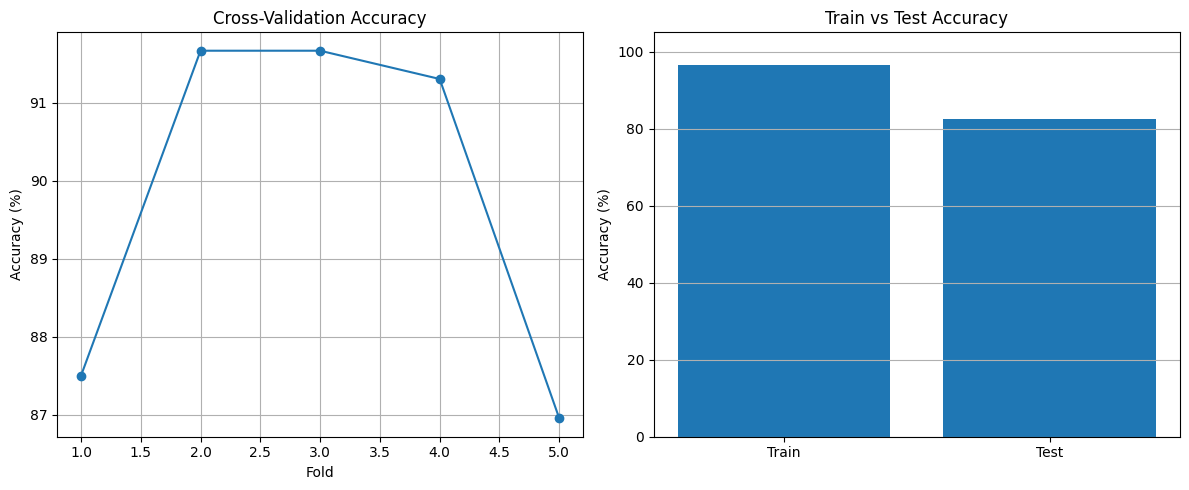

In [133]:
plt.figure(figsize=(12,5))

# Fold accuracy
plt.subplot(1,2,1)
plt.plot(range(1, len(cv_scores)+1),
         cv_scores * 100,
         marker='o')
plt.xlabel('Fold')
plt.ylabel('Accuracy (%)')
plt.title('Cross-Validation Accuracy')
plt.grid(True)

# Train vs Test
plt.subplot(1,2,2)
plt.bar(['Train', 'Test'],
        [nasnet_dvsp_train_acc,
         nasnet_dvsp_test_acc])
plt.ylabel('Accuracy (%)')
plt.title('Train vs Test Accuracy')
plt.ylim(0,105)
plt.grid(axis='y')

plt.tight_layout()
plt.show()
